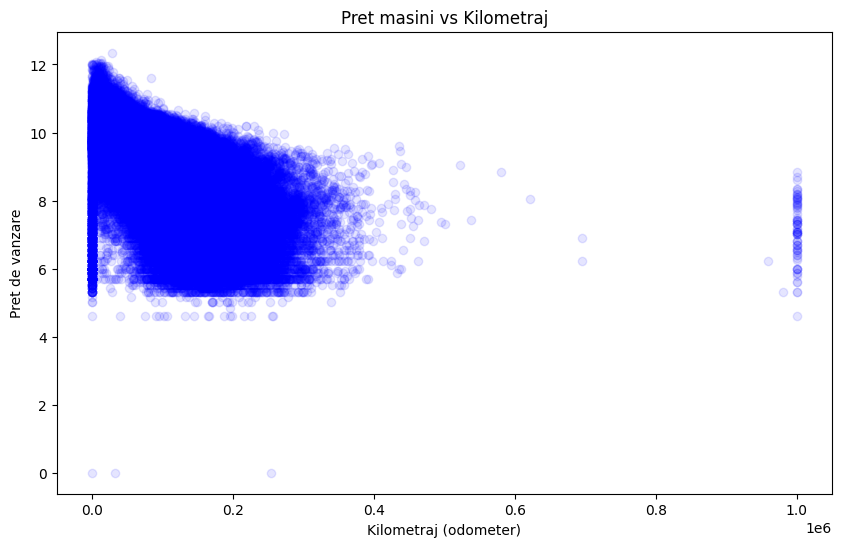

3416.38134765625


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np

car_data = pd.read_csv("car_prices.csv", on_bad_lines='skip')

car_data = car_data[car_data['sellingprice'] > 500]
car_data = car_data[car_data['odometer'] <= 300000]

plt.figure(figsize=(10,6))
plt.scatter(car_data['odometer'], np.log(car_data['sellingprice']), alpha = 0.1, color = 'blue')
plt.title('Pret masini vs Kilometraj')
plt.xlabel('Kilometraj (odometer)')
plt.ylabel('Pret de vanzare')
plt.show()
#print(car_data.shape)
#car_data.head()

y = car_data.sellingprice
features = ['year', 'condition', 'odometer', 'make']
X = car_data[features]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

# acum folosesc pipeline
# partea de preprocess:

coloane_numerice = ['year', 'condition', 'odometer']
num_transformer = SimpleImputer(strategy = 'mean')

coloane_text = ['make']
str_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'constant', fill_value='unknown')),
    ('encoder', OrdinalEncoder(handle_unknown= 'use_encoded_value', unknown_value = -1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, coloane_numerice),
    ('str', str_transformer, coloane_text)
])

# pregatesc modelul:

train_X_curat = preprocessor.fit_transform(train_X)
val_X_curat = preprocessor.transform(val_X)
car_model = XGBRegressor(
    early_stopping_rounds = 5,
        n_estimators = 1000, learning_rate = 0.1, n_jobs = -1
    )# n_jobs ii spune compilatorului ca poate folosi toate nucleele necesare, a scazut timpul de antrenat de la 1.5 minute la 23s

car_model.fit(
    train_X_curat, train_y,
    eval_set = [(val_X_curat, val_y)],
    verbose = False
)

prediction = car_model.predict(val_X_curat)

print(mean_absolute_error(prediction, val_y))

#car_data['make'].nunique() ====>> 96 de valori distince, one hot encoder mi ar bubui calculatorul => cardinal encoder